In [1]:
import numpy as np
import pandas as pd

from tqdm.auto import tqdm

from sklearn.metrics.pairwise import cosine_similarity

import joblib

e:\interview preparation guide\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Embedding Similarity

In [3]:
questions = pd.read_csv("embedding_metadata.csv")

company_question = pd.read_csv("data/processed/company_question.csv")

embeddings = np.load("question_embeddings.npy")

In [33]:
print(questions.shape)

print(company_question.shape)

print(embeddings.shape)

(3358, 2)
(17641, 3)
(3358, 384)


In [35]:
question_lookup = dict(
    zip(
        questions["ID"],
        embeddings
    )
)

In [36]:
question_lookup[101].shape

(384,)

In [38]:
missing = set(company_question.ID) - set(question_lookup.keys())

print(len(missing))

0


In [39]:
company_embeddings = {}

In [40]:
companies = company_question.company.unique()

In [41]:
for company in tqdm(companies):

    qids = company_question.loc[
        company_question.company == company,
        "ID"
    ]

    vectors = []

    for q in qids:

        if q in question_lookup:

            vectors.append(question_lookup[q])

    vectors = np.array(vectors)

    company_embeddings[company] = vectors.mean(axis=0)

100%|██████████| 654/654 [00:02<00:00, 277.38it/s]


In [42]:
company_embedding_df = pd.DataFrame.from_dict(
    company_embeddings,
    orient="index"
)

company_embedding_df.index.name = "company"

company_embedding_df.reset_index(inplace=True)

In [43]:
company_embedding_df.to_csv(
    "company_embedding_mean.csv",
    index=False
)

In [46]:
def company_similarity(

    company,

    embedding_df,

    top_k=10

):

    names = embedding_df.company

    X = embedding_df.drop(

        columns="company"

    ).values

    sim = cosine_similarity(X)

    idx = names[names == company].index[0]

    scores = sim[idx]

    top = np.argsort(scores)[::-1][1:top_k+1]

    result = pd.DataFrame({

        "Company":names.iloc[top].values,

        "Similarity":scores[top]

    })

    return result

In [50]:
company_similarity(

    "tcs",

    company_embedding_df

)

,Company,Similarity
0,accenture,0.994685
1,infosys,0.994412
2,walmart-labs,0.992099
3,bloomberg,0.991436
4,adobe,0.990979
5,nvidia,0.990270
6,yandex,0.990089
7,ibm,0.989908
8,microsoft,0.988904
9,cisco,0.988597


In [51]:
lookup = dict(

zip(

company_embedding_df.company,

company_embedding_df.drop(

columns="company"

).values

)

)

In [52]:
joblib.dump(

lookup,

"company_embedding_lookup.pkl"

)

['company_embedding_lookup.pkl']

### Feature Similarity

In [84]:
import pandas as pd
import numpy as np

company_features = pd.read_csv("data/processed/all_company_feature_final.csv")

In [86]:
company_names = company_features["company"]

In [88]:
company_features

,company,company_tier,total_questions,easy_pct,medium_pct,hard_pct,avg_acceptance,median_acceptance,avg_frequency,median_frequency,...,Segment Tree_pct,Hash Function_pct,Geometry_pct,Shortest Path_pct,String Matching_pct,Bitmask_pct,Monotonic Queue_pct,Combinatorics_pct,Quickselect_pct,Bucket Sort_pct
0,1kosmos,Tier_C,1,0.000000,100.000000,0.000000,63.900000,63.90,100.000000,100.00,...,0.0,0.000000,0.0,0.0,0.000000,0.0000,0.0,0.000000,0.000000,0.000000
1,6sense,Tier_C,7,0.000000,85.714286,14.285714,54.985714,53.20,91.071429,87.50,...,0.0,0.000000,0.0,0.0,0.000000,0.0000,0.0,0.000000,0.000000,0.000000
2,accelya,Tier_C,1,100.000000,0.000000,0.000000,75.200000,75.20,100.000000,100.00,...,0.0,0.000000,0.0,0.0,0.000000,0.0000,0.0,0.000000,0.000000,0.000000
3,accenture,Tier_A,142,45.070423,47.183099,7.746479,59.897887,59.85,52.552817,50.00,...,0.0,0.007042,0.0,0.0,0.014085,0.0000,0.0,0.007042,0.007042,0.014085
4,accolite,Tier_C,20,20.000000,75.000000,5.000000,51.790000,50.90,69.375000,62.50,...,0.0,0.000000,0.0,0.0,0.000000,0.0000,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
649,zopsmart,Tier_C,19,15.789474,68.421053,15.789474,58.021053,60.00,50.657895,62.50,...,0.0,0.000000,0.0,0.0,0.000000,0.0000,0.0,0.000000,0.000000,0.000000
650,zs-associates,Tier_C,10,20.000000,80.000000,0.000000,48.060000,45.60,45.000000,37.50,...,0.0,0.000000,0.0,0.0,0.000000,0.0000,0.0,0.000000,0.000000,0.000000
651,zscaler,Tier_C,16,18.750000,50.000000,31.250000,53.668750,51.80,57.031250,56.25,...,0.0,0.000000,0.0,0.0,0.000000,0.0625,0.0,0.000000,0.000000,0.000000
652,zulily,Tier_C,2,50.000000,50.000000,0.000000,43.550000,43.55,56.250000,56.25,...,0.0,0.000000,0.0,0.0,0.000000,0.0000,0.0,0.000000,0.000000,0.000000


In [89]:
X = company_features.select_dtypes(include=np.number)

In [90]:
company_names

0            1kosmos
1             6sense
2            accelya
3          accenture
4           accolite
           ...      
649         zopsmart
650    zs-associates
651          zscaler
652           zulily
653            zynga
Name: company, Length: 654, dtype: str

In [91]:
X.head()

,total_questions,easy_pct,medium_pct,hard_pct,avg_acceptance,median_acceptance,avg_frequency,median_frequency,avg_likes,avg_dislikes,...,Segment Tree_pct,Hash Function_pct,Geometry_pct,Shortest Path_pct,String Matching_pct,Bitmask_pct,Monotonic Queue_pct,Combinatorics_pct,Quickselect_pct,Bucket Sort_pct
0,1,0.000000,100.000000,0.000000,63.900000,63.90,100.000000,100.0,832.000000,41.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000
1,7,0.000000,85.714286,14.285714,54.985714,53.20,91.071429,87.5,2246.714286,322.571429,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000
2,1,100.000000,0.000000,0.000000,75.200000,75.20,100.000000,100.0,186.000000,18.000000,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000
3,142,45.070423,47.183099,7.746479,59.897887,59.85,52.552817,50.0,11970.617021,1557.992908,...,0.0,0.007042,0.0,0.0,0.014085,0.0,0.0,0.007042,0.007042,0.014085
4,20,20.000000,75.000000,5.000000,51.790000,50.90,69.375000,62.5,20886.736842,1335.894737,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000


In [92]:
X.shape

(654, 60)

In [93]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 654 entries, 0 to 653
Data columns (total 60 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   total_questions            654 non-null    int64  
 1   easy_pct                   654 non-null    float64
 2   medium_pct                 654 non-null    float64
 3   hard_pct                   654 non-null    float64
 4   avg_acceptance             654 non-null    float64
 5   median_acceptance          654 non-null    float64
 6   avg_frequency              654 non-null    float64
 7   median_frequency           654 non-null    float64
 8   avg_likes                  654 non-null    float64
 9   avg_dislikes               654 non-null    float64
 10  Array_pct                  654 non-null    float64
 11  String_pct                 654 non-null    float64
 12  Hash Table_pct             654 non-null    float64
 13  Dynamic Programming_pct    654 non-null    float64
 14  Sorti

In [94]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

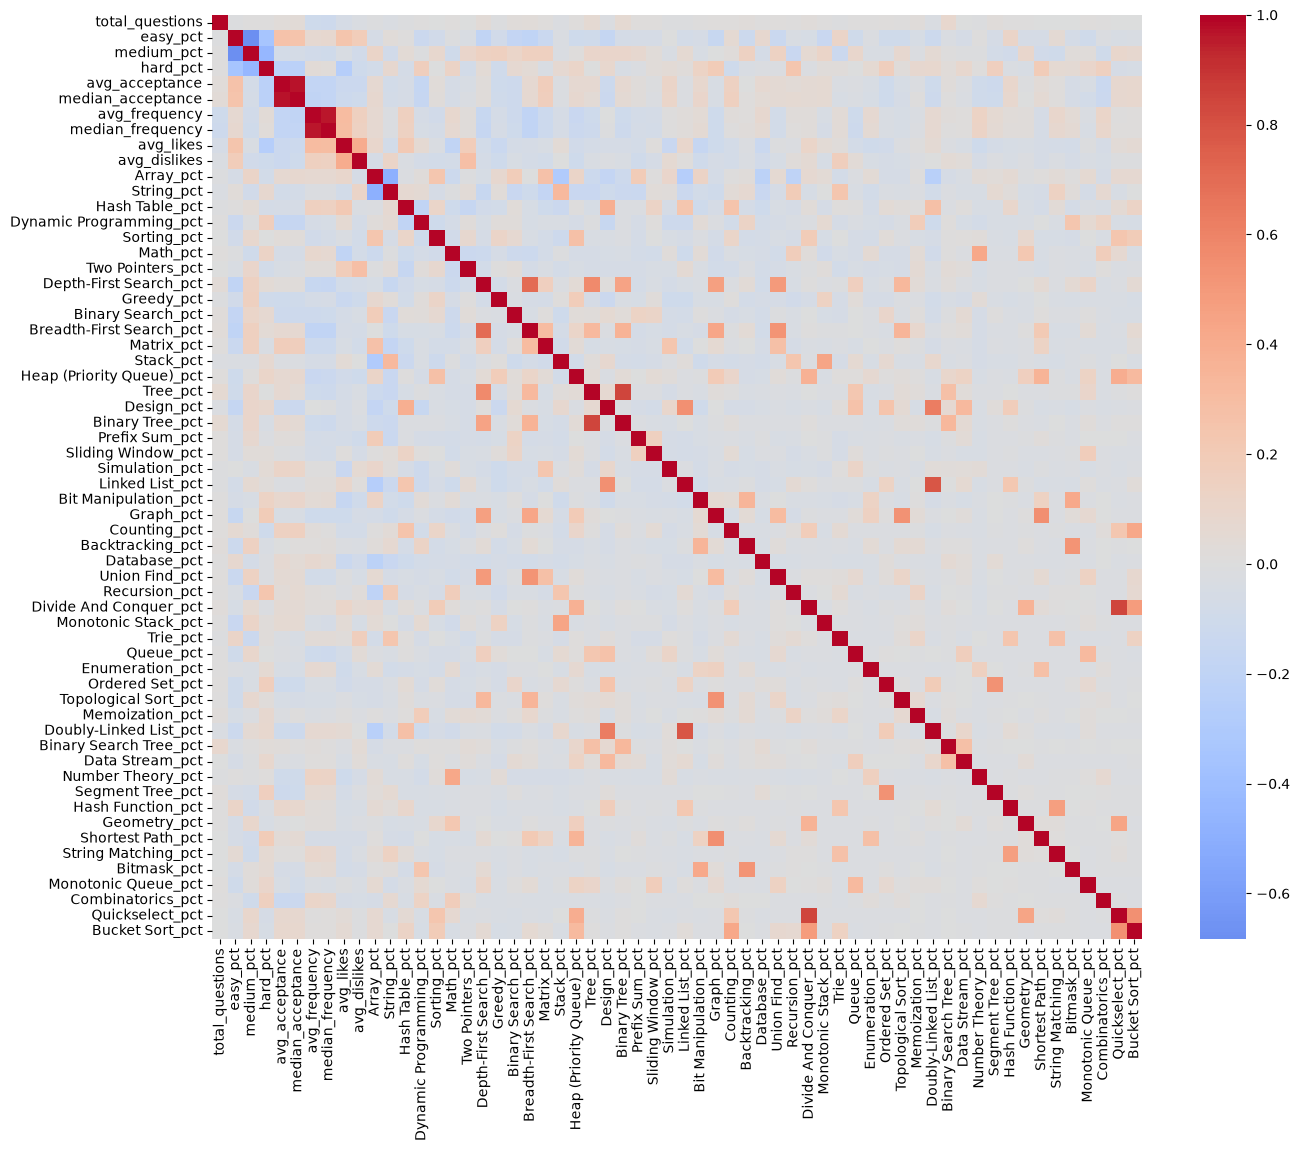

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,12))

sns.heatmap(
    X.corr(),
    cmap="coolwarm",
    center=0
)

plt.show()

In [96]:
variance = pd.Series(
    X_scaled.var(),
    index=X.columns
).sort_values()

In [108]:
# variance.plot.barh(figsize=(8,10))

In [97]:
from sklearn.metrics.pairwise import cosine_similarity

feature_similarity = cosine_similarity(
    X_scaled
)

In [98]:
feature_similarity

array([[ 1.        ,  0.06747878,  0.0368665 , ..., -0.07526066,
         0.15479775, -0.06286455],
       [ 0.06747878,  1.        ,  0.01110579, ..., -0.01367977,
        -0.03223943, -0.10449349],
       [ 0.0368665 ,  0.01110579,  1.        , ...,  0.16242913,
        -0.07711796,  0.00117937],
       ...,
       [-0.07526066, -0.01367977,  0.16242913, ...,  1.        ,
        -0.10117915,  0.11859735],
       [ 0.15479775, -0.03223943, -0.07711796, ..., -0.10117915,
         1.        , -0.183221  ],
       [-0.06286455, -0.10449349,  0.00117937, ...,  0.11859735,
        -0.183221  ,  1.        ]], shape=(654, 654))

In [99]:
feature_similarity = pd.DataFrame(
    feature_similarity,
    index=company_names,
    columns=company_names
)

In [100]:
def similar_companies(company, top_k=10):

    scores = (
        feature_similarity
        .loc[company]
        .sort_values(ascending=False)
    )

    return scores.iloc[1:top_k+1]


In [101]:
similar_companies("google")

company
amazon           0.999064
microsoft        0.994192
meta             0.992236
bloomberg        0.989364
oracle           0.849559
goldman-sachs    0.826657
tiktok           0.805175
apple            0.795742
uber             0.785371
tcs              0.622989
Name: google, dtype: float64

### Hybrid Similarity

In [102]:
company_embeddings = pd.read_csv(
    "company_embedding_mean.csv"
)

In [103]:
embedding_names = company_embeddings["company"]

embedding_matrix = company_embeddings.drop(
    columns="company"
)

In [104]:
embedding_similarity = cosine_similarity(
    embedding_matrix
)

In [120]:
feature_sim = feature_similarity.loc["tcs"]

embedding_sim = pd.Series(
    embedding_similarity[
        embedding_names[
            embedding_names=="tcs"
        ].index[0]
    ],
    index=embedding_names
)

In [121]:
comparison = pd.DataFrame({

    "Feature Similarity":feature_sim,

    "Embedding Similarity":embedding_sim

})

comparison.sort_values(
    "Embedding Similarity",
    ascending=False
).head(15)

,Feature Similarity,Embedding Similarity
company,,
tcs,1.000000,1.000000
accenture,0.826470,0.994685
infosys,0.701559,0.994412
walmart-labs,0.363934,0.992099
bloomberg,0.681536,0.991436
adobe,0.406774,0.990979
nvidia,0.493350,0.990270
yandex,0.567007,0.990088
ibm,0.683271,0.989907


In [148]:
alpha = 0.85  # weight for semantic similarity

hybrid_similarity = (
    alpha * embedding_similarity
    + (1 - alpha) * feature_similarity.values
)

In [149]:
hybrid_similarity = pd.DataFrame(
    hybrid_similarity,
    index=company_names,
    columns=company_names
)

In [150]:
hybrid_similarity.shape

(654, 654)

In [151]:
def similar_companies(company, top_k=10):

    scores = (
        hybrid_similarity
        .loc[company]
        .sort_values(ascending=False)
    )

    return scores.iloc[1:top_k+1]

In [153]:
similar_companies('google')

company
amazon           0.999525
meta             0.997861
microsoft        0.997439
bloomberg        0.995318
oracle           0.968972
goldman-sachs    0.965107
tiktok           0.964381
uber             0.961256
apple            0.960806
salesforce       0.929620
Name: google, dtype: float64